In [1]:
# Module 3 — Geospatial Python
import ee
import geemap
import folium
import geopandas as gpd
import numpy as np
import pandas as pd

print("All libraries imported successfully")
print(f"geemap version: {geemap.__version__}")
print(f"folium version: {folium.__version__}")

All libraries imported successfully
geemap version: 0.38.3
folium version: 0.20.0


In [3]:
# Authenticate and initialize GEE
ee.Authenticate()

True

In [ ]:
ee.Authenticate(auth_mode='notebook')

In [ ]:
ee.Authenticate(auth_mode='gcloud')

In [1]:
import ee
ee.Authenticate(auth_mode='localhost')

True

In [2]:
import ee
ee.Initialize(project='extreme-flame-286107')
print("GEE connected successfully!")

EEException: Google Earth Engine API has not been used in project extreme-flame-286107 before or it is disabled. Enable it by visiting https://console.developers.google.com/apis/api/earthengine.googleapis.com/overview?project=extreme-flame-286107 then retry. If you enabled this API recently, wait a few minutes for the action to propagate to our systems and retry.

In [3]:
import ee
ee.Initialize(project='extreme-flame-286107')
print("GEE connected successfully!")

EEException: Project extreme-flame-286107 is not registered to use Earth Engine. Visit https://console.cloud.google.com/earth-engine/configuration?project=extreme-flame-286107 to register your project. See https://developers.google.com/earth-engine/guides/access for more details.

In [1]:
import ee
ee.Initialize(project='extreme-flame-286107')
print("GEE connected successfully!")

KeyboardInterrupt: 

In [ ]:
import ee

ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='extreme-flame-286107')

print("GEE connected successfully!")


In [1]:
import ee
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='extreme-flame-286107')
print("GEE connected successfully!")

GEE connected successfully!


In [2]:
import ee
ee.Initialize(project='extreme-flame-286107')

# Test — get basic info from GEE
image = ee.Image('LANDSAT/LC08/C02/T1_L2/LC08_148_040_20230512')
print(image.getInfo()['id'])
print("GEE connected and Landsat data accessible!")

EEException: Image.load: Image asset 'LANDSAT/LC08/C02/T1_L2/LC08_148_040_20230512' not found (does not exist or caller does not have access).

In [3]:
# Test GEE connection properly
import ee
ee.Initialize(project='extreme-flame-286107')

# Search for Landsat 8 images over Jaipur
jaipur = ee.Geometry.Point([75.7873, 26.9124])

collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(jaipur) \
    .filterDate('2023-04-01', '2023-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10))

# Count available images
count = collection.size().getInfo()
print(f"Available Landsat 8 images over Jaipur: {count}")

# Get the least cloudy image date
first = collection.sort('CLOUD_COVER').first()
date = first.date().format('YYYY-MM-dd').getInfo()
cloud = first.get('CLOUD_COVER').getInfo()
print(f"Best image date: {date}")
print(f"Cloud cover: {cloud:.1f}%")
print("GEE fully working!")

Available Landsat 8 images over Jaipur: 2
Best image date: 2023-04-14
Cloud cover: 1.4%
GEE fully working!


In [4]:
# Pull real Landsat 8 LST for Jaipur

# Define Jaipur boundary
jaipur = ee.Geometry.Point([75.7873, 26.9124]).buffer(15000)

# Get the best image
image = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(jaipur) \
    .filterDate('2023-04-01', '2023-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
    .sort('CLOUD_COVER') \
    .first()

# Compute LST in Celsius
lst = image.select('ST_B10') \
           .multiply(0.00341802) \
           .add(149.0) \
           .subtract(273.15) \
           .rename('LST_Celsius')

# Clip to Jaipur
lst_jaipur = lst.clip(jaipur)

# Get real statistics
stats = lst_jaipur.reduceRegion(
    reducer=ee.Reducer.min()
        .combine(ee.Reducer.max(), '', True)
        .combine(ee.Reducer.mean(), '', True)
        .combine(ee.Reducer.stdDev(), '', True),
    geometry=jaipur,
    scale=30,
    maxPixels=1e9
).getInfo()

print("Real Jaipur LST Statistics — April 14, 2023")
print("=" * 45)
print(f"Min LST:  {stats['LST_Celsius_min']:.1f}°C")
print(f"Max LST:  {stats['LST_Celsius_max']:.1f}°C")
print(f"Mean LST: {stats['LST_Celsius_mean']:.1f}°C")
print(f"Std Dev:  {stats['LST_Celsius_stdDev']:.2f}°C")

Real Jaipur LST Statistics — April 14, 2023
Min LST:  26.2°C
Max LST:  43.4°C
Mean LST: 35.9°C
Std Dev:  1.66°C


In [5]:
# Visualize real LST on interactive map
import geemap

# Create map centered on Jaipur
Map = geemap.Map(center=[26.9124, 75.7873], zoom=11)

# LST color palette
lst_palette = [
    '040274', '0602ff', '235cb1', '307ef3',
    '30c8e2', '3be285', '86e26f', 'd6e21f',
    'fff705', 'ffd611', 'ffb613', 'ff8b13',
    'ff6e08', 'ff500d', 'ff0000', 'de0101',
    'a71001', '911003'
]

# Visualization parameters
lst_vis = {
    'min': 25,
    'max': 45,
    'palette': lst_palette
}

# Add LST layer
Map.addLayer(lst_jaipur, lst_vis, 'LST Jaipur — April 2023')

# Add Jaipur boundary
Map.addLayer(
    ee.FeatureCollection([ee.Feature(jaipur)]),
    {'color': 'white'},
    'Jaipur boundary'
)

# Add colorbar
Map.add_colorbar(lst_vis, label="LST (°C)", 
                 orientation="horizontal")

# Display
Map

Map(center=[26.9124, 75.7873], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [6]:
# Compute real NDVI for Jaipur

# Apply scale factors to optical bands
def apply_scale_factors(image):
    optical = image.select('SR_B.') \
                   .multiply(0.0000275) \
                   .add(-0.2)
    return image.addBands(optical, None, True)

image_scaled = apply_scale_factors(image)

# NDVI = (NIR - Red) / (NIR + Red)
# Band 5 = NIR, Band 4 = Red
ndvi = image_scaled.normalizedDifference(['SR_B5', 'SR_B4']) \
                   .rename('NDVI') \
                   .clip(jaipur)

# Get real NDVI statistics
ndvi_stats = ndvi.reduceRegion(
    reducer=ee.Reducer.min()
        .combine(ee.Reducer.max(), '', True)
        .combine(ee.Reducer.mean(), '', True),
    geometry=jaipur,
    scale=30,
    maxPixels=1e9
).getInfo()

print("Real Jaipur NDVI Statistics — April 14, 2023")
print("=" * 45)
print(f"Min NDVI:  {ndvi_stats['NDVI_min']:.3f}")
print(f"Max NDVI:  {ndvi_stats['NDVI_max']:.3f}")
print(f"Mean NDVI: {ndvi_stats['NDVI_mean']:.3f}")

# Add NDVI to map
ndvi_vis = {
    'min': -0.2,
    'max': 0.6,
    'palette': ['brown', 'yellow', 'lightgreen', 'darkgreen']
}

Map.addLayer(ndvi, ndvi_vis, 'NDVI Jaipur — April 2023')
Map

Real Jaipur NDVI Statistics — April 14, 2023
Min NDVI:  -0.013
Max NDVI:  0.814
Mean NDVI: 0.333


Map(bottom=55657.0, center=[26.90982467124072, 76.09545570397788], controls=(WidgetControl(options=['position'…

Real pixel samples: 151
Real LST-NDVI correlation: -0.451

LST range: 31.6 — 40.3°C
NDVI range: 0.129 — 0.652


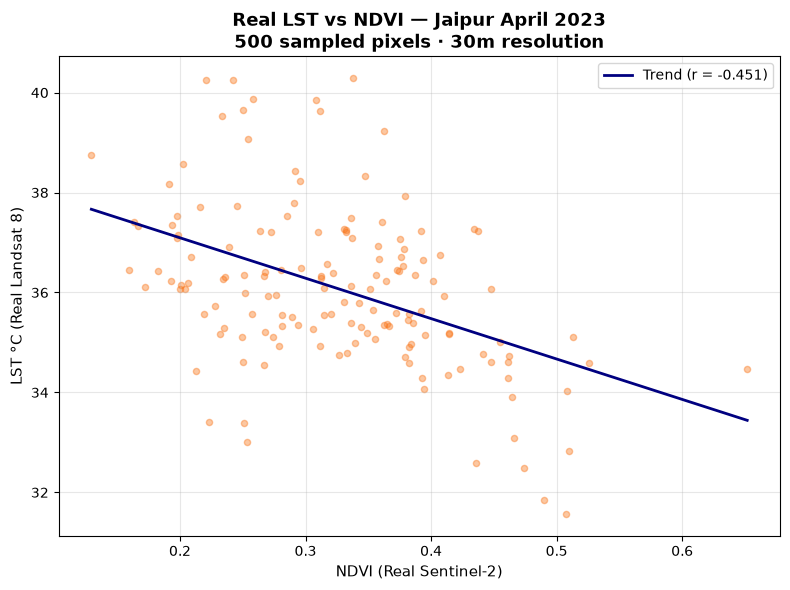

Chart saved


In [7]:
# Compute real LST-NDVI correlation over Jaipur

# Stack LST and NDVI into one image
combined = lst_jaipur.addBands(ndvi)

# Sample random pixels from the image
samples = combined.sample(
    region=jaipur,
    scale=100,
    numPixels=500,
    seed=42
)

# Convert to pandas dataframe
sample_list = samples.getInfo()['features']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract values
lst_vals  = [f['properties']['LST_Celsius'] for f in sample_list]
ndvi_vals = [f['properties']['NDVI'] for f in sample_list]

df_real = pd.DataFrame({
    'lst': lst_vals,
    'ndvi': ndvi_vals
})

# Remove outliers
df_real = df_real[
    (df_real['lst'] > 20) & 
    (df_real['lst'] < 55) &
    (df_real['ndvi'] > -0.1) & 
    (df_real['ndvi'] < 1.0)
]

# Compute real correlation
corr = df_real['lst'].corr(df_real['ndvi'])
print(f"Real pixel samples: {len(df_real)}")
print(f"Real LST-NDVI correlation: {corr:.3f}")
print()
print(f"LST range: {df_real['lst'].min():.1f} — {df_real['lst'].max():.1f}°C")
print(f"NDVI range: {df_real['ndvi'].min():.3f} — {df_real['ndvi'].max():.3f}")

# Plot scatter
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_real['ndvi'], df_real['lst'], 
           alpha=0.4, s=20, color='#F97316')

# Trend line
z = np.polyfit(df_real['ndvi'], df_real['lst'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_real['ndvi'].min(), 
                     df_real['ndvi'].max(), 100)
ax.plot(x_line, p(x_line), 'navy', linewidth=2,
        label=f'Trend (r = {corr:.3f})')

ax.set_xlabel("NDVI (Real Sentinel-2)", fontsize=11)
ax.set_ylabel("LST °C (Real Landsat 8)", fontsize=11)
ax.set_title("Real LST vs NDVI — Jaipur April 2023\n"
             "500 sampled pixels · 30m resolution",
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("real_lst_ndvi_correlation.png", dpi=150, 
            bbox_inches='tight')
plt.show()
print("Chart saved")